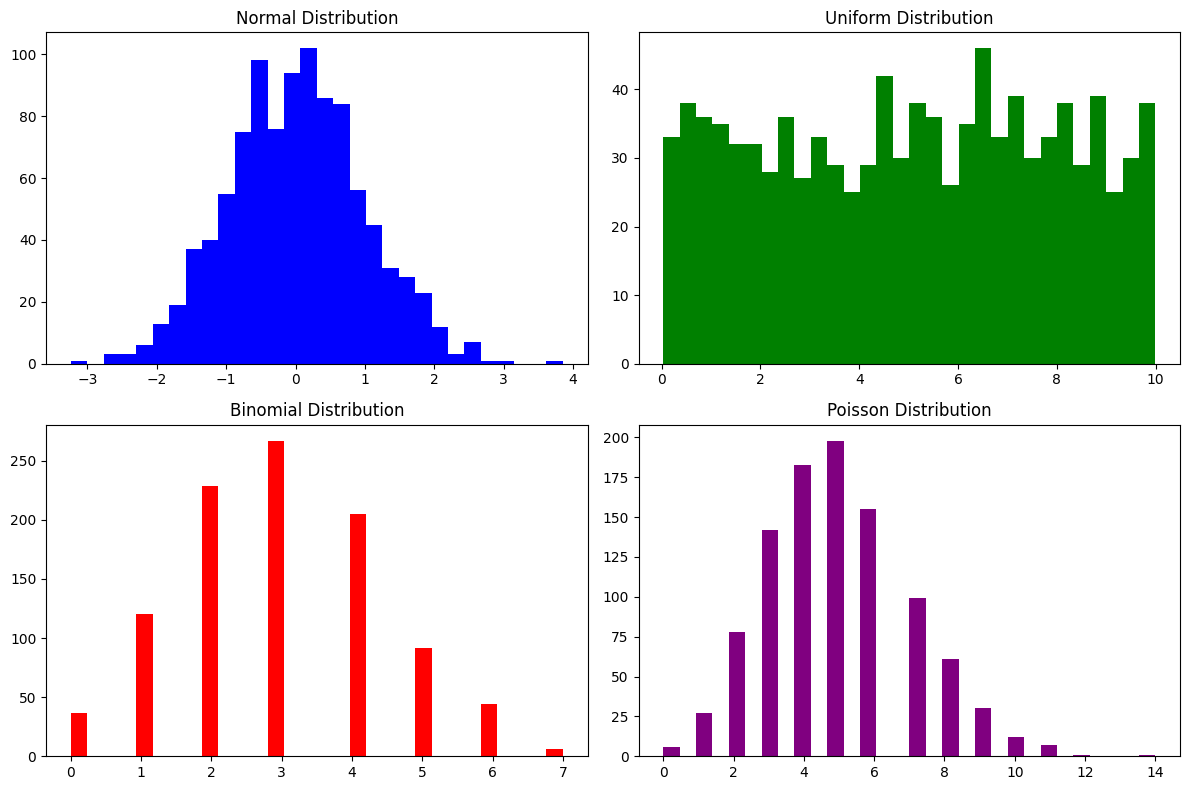

In [6]:
#  EXERCISE 1: SAMPLING From DISTRIBUTIONS

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)


normal_data   = np.random.normal(loc=0, scale=1, size=1000)
uniform_data  = np.random.uniform(low=0, high=10, size=1000)
binomial_data = np.random.binomial(n=10, p=0.3, size=1000)
poisson_data  = np.random.poisson(lam=5, size=1000)


# Task: plot all 4 as histograms in one figure (2x2 grid)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(normal_data, color="blue", bins=30)
axes[0,0].set_title("Normal Distribution")

axes[0,1].hist(uniform_data, color="green", bins=30)
axes[0,1].set_title("Uniform Distribution")

axes[1,0].hist(binomial_data, color="red", bins=30)
axes[1,0].set_title("Binomial Distribution")

axes[1,1].hist(poisson_data, color="purple", bins=30)
axes[1,1].set_title("Poisson Distribution")

plt.tight_layout()
plt.show()

In [17]:
# Mean and Standard Deviation of each distribution

Data = [normal_data, uniform_data, binomial_data, poisson_data]
names = ["Normal", "Uniform", "Binomial", "Poisson"]
for i in range(len(Data)):
    print("Mean of ", names[i], "Distribution:", Data[i].mean())
    print("Standard Deviation of", names[i], "Distribution:", Data[i].std())


Mean of  Normal Distribution: 0.01933205582232549
Standard Deviation of Normal Distribution: 0.9787262077473543
Mean of  Uniform Distribution: 5.036488055234082
Standard Deviation of Uniform Distribution: 2.882126205844779
Mean of  Binomial Distribution: 2.965
Standard Deviation of Binomial Distribution: 1.4511288709139516
Mean of  Poisson Distribution: 4.935
Standard Deviation of Poisson Distribution: 2.0719013007380447


In [ ]:
#  Exercise 2: Outlier Detection using STD

prices = np.array([
    45, 52, 48, 61, 55, 49, 58, 250,
    51, 46, 53, 310, 57, 44, 60, 48,
    52, 55, 49, 1200, 47, 53, 51, 56
])

mean = prices.mean()
std = prices.std()

z_scores = (prices - mean)/std

outliers = prices[np.abs(z_scores)>3]
clean_prices = prices[np.abs(z_scores) <=3]

print(f"Mean:     ₹{mean:.1f}L")
print(f"Std:      ₹{std:.1f}L")
print(f"Outliers: {outliers}")
print(f"Clean mean: ₹{clean_prices.mean():.1f}L")

Mean:     ₹118.8L
Std:      ₹234.3L
Outliers: [1200]
Clean mean: ₹71.7L


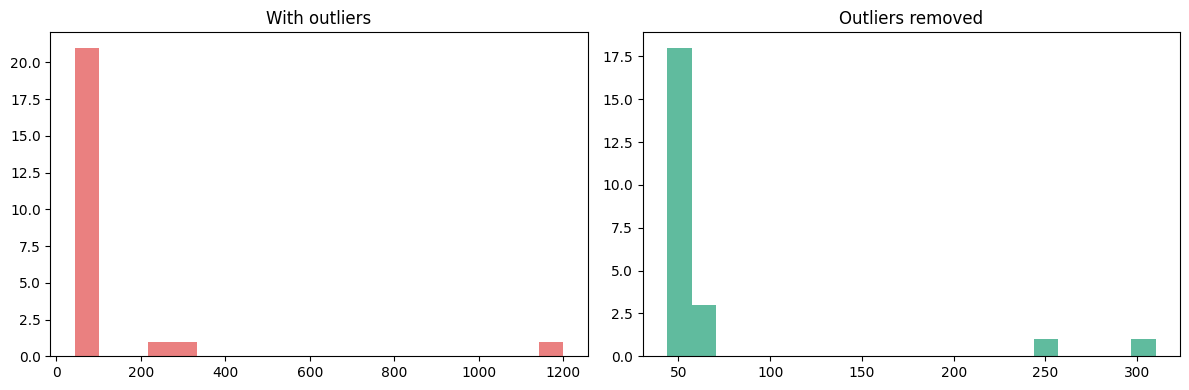

In [4]:
#  Plotting original vs clean prices

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(prices, bins=20, color='#E24B4A', alpha=0.7)
ax1.set_title('With outliers')
ax2.hist(clean_prices, bins=20, color='#1D9E75', alpha=0.7)
ax2.set_title('Outliers removed')
plt.tight_layout()
plt.show()

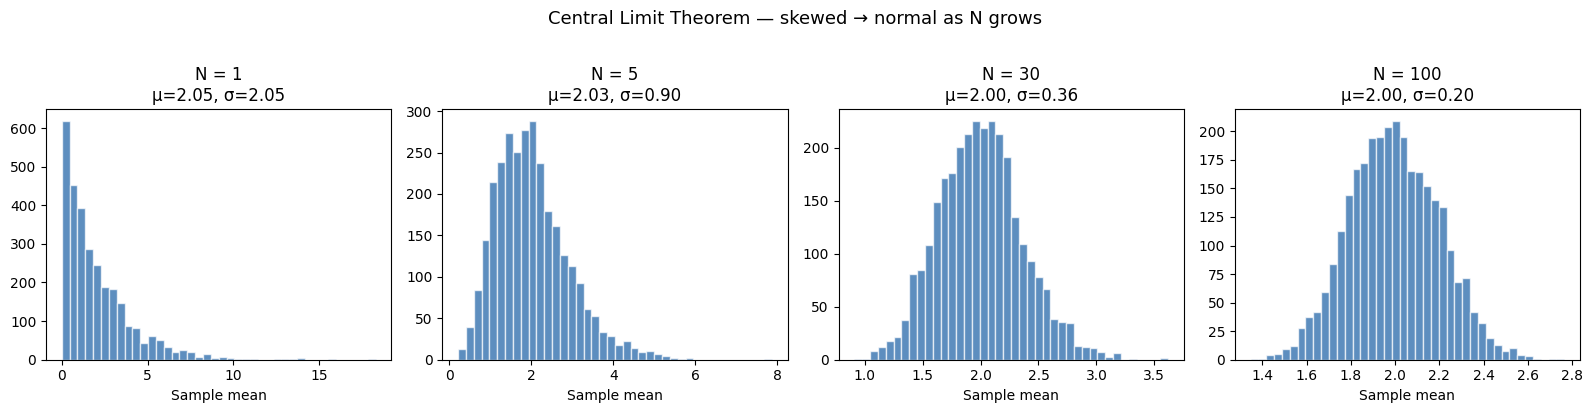

In [4]:
# Exercise 3: Central Limit Theorem in code

population = np.random.exponential(scale=2, size=100000)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sample_sizes = [1, 5, 30, 100]

for i, N in enumerate(sample_sizes):
    sample_means = [
        np.mean(np.random.choice(population, size=N))
        for i in range(3000)
    ]
    axes[i].hist(sample_means, bins=40,
                 color='#185FA5', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'N = {N}\nμ={np.mean(sample_means):.2f}, '
                      f'σ={np.std(sample_means):.2f}')
    axes[i].set_xlabel('Sample mean')

plt.suptitle('Central Limit Theorem — skewed → normal as N grows',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

1. At what N does the distribution start looking normal?

At N = 30, we can see that our Distribution is looking like normal but not completly normal.

2. What happens to the std of sample means as N increases?

The standard deviation (sigma) of means is decreasing as N increases.

3. Why does this matter for ML?

I think it matters in ML because by looking at the graphs and std values we can see the trend and changes in the data more clearly as visuals give a better perspective. We also clearly identified that 'When our distribution starts looking like normal' because we can see it on the graph.

In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X = np.array([
    [1500,  3, 25,  50.0],
    [ 800,  1, 22,   7.5],
    [2200,  5, 35, 512.3],
    [1200,  2, 28,  15.0],
    [1800,  4, 45, 263.0],
], dtype=float)

feature_names = ['size', 'bedrooms', 'age', 'fare']

def my_standard_scaler(X):
    mean =X.mean(axis=0)
    std = X.std(axis=0)
    return (X - mean) / std, mean, std

X_scaled, mean, std = my_standard_scaler(X)

scaler = StandardScaler()
X_sklearn = scaler.fit_transform(X)

print("Match:", np.allclose(X_scaled, X_sklearn))

print("\nBefore scaling:")
for i, name in enumerate(feature_names):
    print(f"  {name:10s}: mean={X[:,i].mean():.1f}, std={X[:,i].std():.1f}")

print("\nAfter scaling:")
for i, name in enumerate(feature_names):
    print(f"  {name:10s}: mean={X_scaled[:,i].mean():.2f}, std={X_scaled[:,i].std():.2f}")
    
z_fare_extreme = (512.3 - mean[3]) / std[3]
print(f"\nZ-score of fare 512.3: {z_fare_extreme:.2f}")
print("Outlier?" , abs(z_fare_extreme) > 2)

Match: True

Before scaling:
  size      : mean=1500.0, std=481.7
  bedrooms  : mean=3.0, std=1.4
  age       : mean=31.0, std=8.2
  fare      : mean=169.6, std=195.3

After scaling:
  size      : mean=0.00, std=1.00
  bedrooms  : mean=0.00, std=1.00
  age       : mean=-0.00, std=1.00
  fare      : mean=-0.00, std=1.00

Z-score of fare 512.3: 1.76
Outlier? False


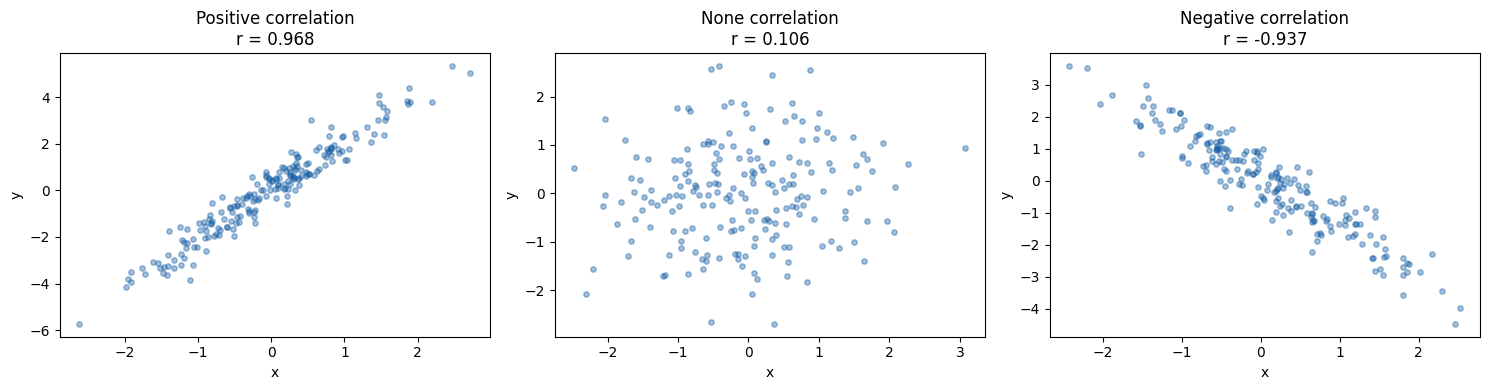

Numpy check:
  Pair 1: 0.968
  Pair 2: 0.106
  Pair 3: -0.937


In [17]:
#  Exercise 5: Covariance and correlation

np.random.seed(42)
n = 200

#  Strong Positive correlation
x1 = np.random.normal(0,1,n)
y1 = 2*x1 + np.random.normal(0,0.5,n)

#  No correlation
x2 = np.random.normal(0,1,n)
y2 = np.random.normal(0,1,n)

#  Strong Negative correlation
x3 = np.random.normal(0,1,n)
y3 = -1.5*x3 + np.random.normal(0,0.5,n)

#  Putting all x1,x2,x3 & y1,y2,y3 in a list x,y
x = [x1,x2,x3]
y = [y1,y2,y3]


def correlation(x,y): 
    x_mean = np.mean(x)
    x_std = np.std(x)

    y_mean = np.mean(y)
    y_std = np.std(y)
    
    cov = np.mean((x-x_mean)*(y-y_mean))
    
    corr = cov / (x_std * y_std)
    
    return corr

corr1 = correlation(x1,y1)
corr2 = correlation(x2,y2)
corr3 = correlation(x3,y3)

#  Plotting all 3 scatter plots

fig,axes = plt.subplots(1,3, figsize=(15,4))
pairs = [(x1,y1,corr1,'Positive'),(x2,y2,corr2,'None'),(x3,y3,corr3,'Negative')]

for ax, (x, y, corr, title) in zip(axes, pairs):
    ax.scatter(x, y, alpha=0.4, s=15, color='#185FA5')
    ax.set_title(f'{title} correlation\nr = {corr:.3f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

#  Verifying with Numpy

print("Numpy check:")
print(f"  Pair 1: {np.corrcoef(x1,y1)[0,1]:.3f}")
print(f"  Pair 2: {np.corrcoef(x2,y2)[0,1]:.3f}")
print(f"  Pair 3: {np.corrcoef(x3,y3)[0,1]:.3f}")


Age:
  mean=29.70, median=28.00
  std=14.53, min=0.42, max=80.0
  skew=0.39  (approx normal)

Fare:
  mean=32.20, median=14.45
  std=49.69, min=0.0, max=512.3292
  skew=4.77  (right skewed)

SibSp:
  mean=0.52, median=0.00
  std=1.10, min=0, max=8
  skew=3.68  (right skewed)

Parch:
  mean=0.38, median=0.00
  std=0.81, min=0, max=6
  skew=2.74  (right skewed)


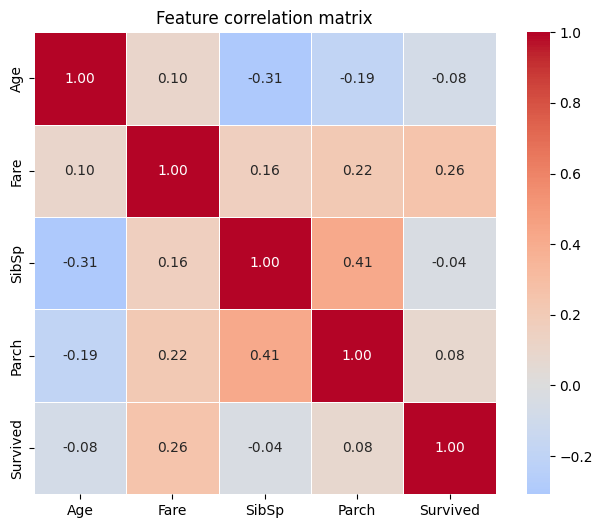


=== Survival group comparison ===
Age: survived mean=28.3, died mean=30.6, p=0.0391 ← significant!
Fare: survived mean=48.4, died mean=22.1, p=0.0000 ← significant!


In [19]:
import pandas as pd
import seaborn as sns

train = pd.read_csv(r'C:\Users\Hp\.vscode\Journey to the BEST\Week 1\train.csv')

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

for col in numeric_cols:
    data = train[col].dropna()
    skew = ((data - data.mean())**3).mean() / data.std()**3
    print(f"\n{col}:")
    print(f"  mean={data.mean():.2f}, median={data.median():.2f}")
    print(f"  std={data.std():.2f}, min={data.min()}, max={data.max()}")
    print(f"  skew={skew:.2f}  {'(right skewed)' if skew>0.5 else '(left skewed)' if skew<-0.5 else '(approx normal)'}")
    
corr_matrix = train[numeric_cols + ['Survived']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature correlation matrix')
plt.show()

from scipy import stats

print("\n=== Survival group comparison ===")
for col in ['Age', 'Fare']:
    survived = train[train['Survived']==1][col].dropna()
    died     = train[train['Survived']==0][col].dropna()
    t_stat, p_val = stats.ttest_ind(survived, died)
    print(f"{col}: survived mean={survived.mean():.1f}, "
          f"died mean={died.mean():.1f}, p={p_val:.4f} "
          f"{'← significant!' if p_val < 0.05 else ''}")